In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO



--- 資料集基本資訊 ---
總影像張數: 112120
不重複病患數: 30805

偵測到的所有獨立疾病種類: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

--- 1. 各疾病獨立總計 (不論單獨或組合出現) ---
No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64




/tmp/ipykernel_59629/2314243587.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, palette="viridis")


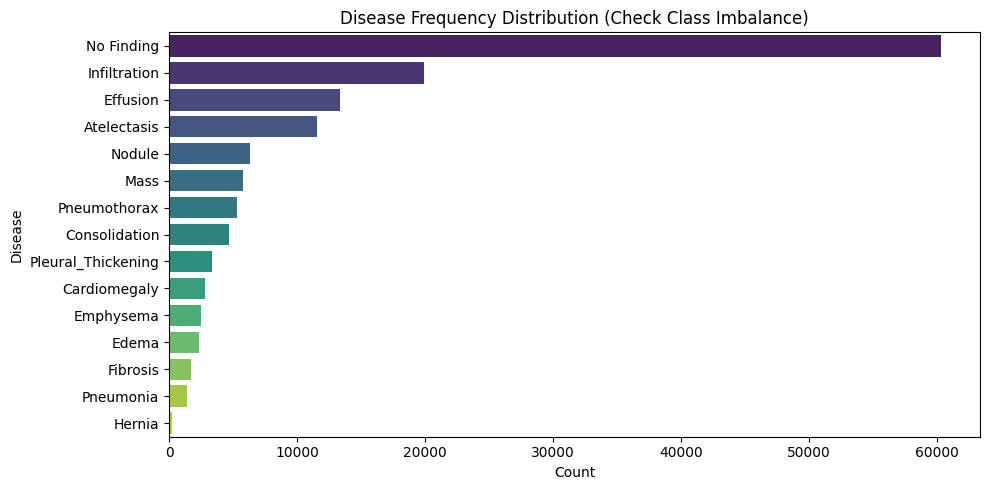

--- 3. 疾病共病矩陣 ---
                    Atelectasis  Cardiomegaly  Consolidation  Edema  Effusion  \
Atelectasis               11559           370           1223    221      3275   
Cardiomegaly                370          2776            169    127      1063   
Consolidation              1223           169           4667    162      1287   
Edema                       221           127            162   2303       593   
Effusion                   3275          1063           1287    593     13317   
Emphysema                   424            44            103     30       359   
Fibrosis                    220            52             79      9       188   
Hernia                       40             7              4      3        21   
Infiltration               3264           587           1221    981      4000   
Mass                        739           102            610    129      1254   
Nodule                      590           108            428    131       912   
Pleural_Th

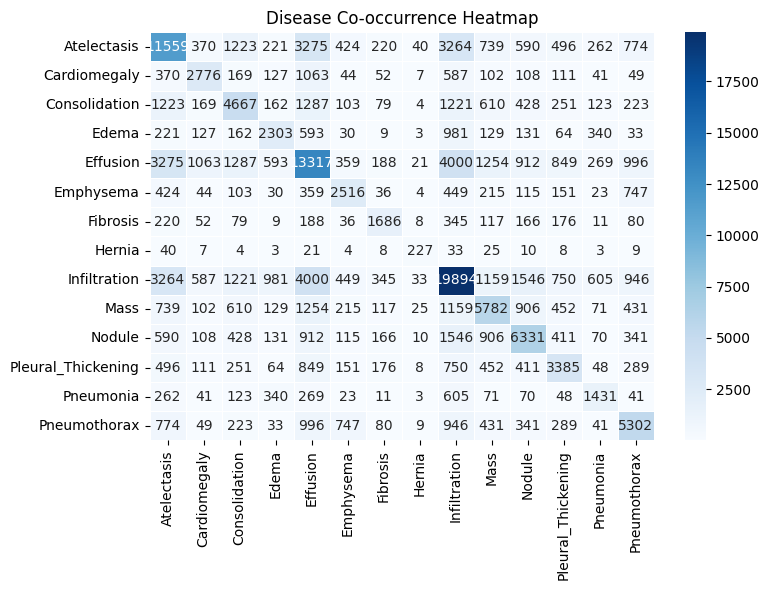

--- 4. PA/AP 姿勢 vs 健康狀態交叉表 ---
Health Status  Healthy   Sick
View Position                
AP               21059  23751
PA               39302  28008


--- PA/AP 姿勢 vs 健康狀態比例 (%) ---
Health Status  Healthy   Sick
View Position                
AP               47.00  53.00
PA               58.39  41.61




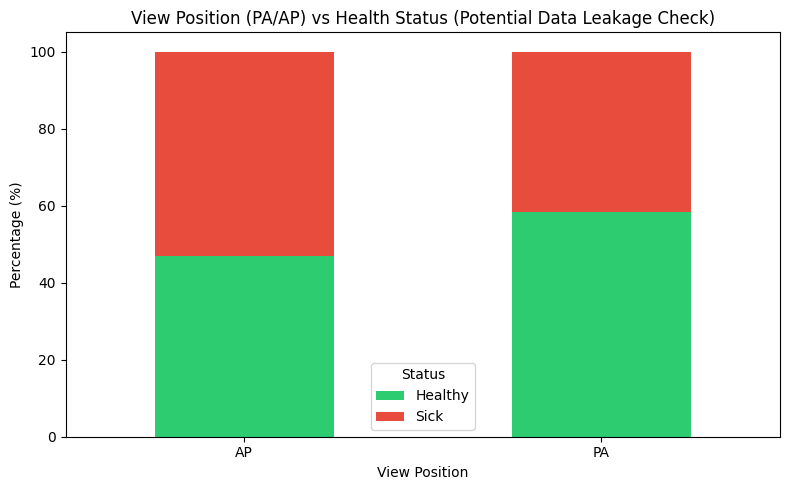

In [6]:
df = pd.read_csv("data/original/Data_Entry_2017.csv")
# 清洗欄位名稱（去除前後空格）
df.columns = df.columns.str.strip()

print("--- 資料集基本資訊 ---")
print(f"總影像張數: {len(df)}")
print(f"不重複病患數: {df['Patient ID'].nunique()}\n")

# =====================================================================
# 考量 1 & 2：疾病獨立數量統計 與 多標籤轉換 (One-Hot Encoding)
# =====================================================================
# 找出所有不重複的疾病標籤
all_labels = set()
df['Finding Labels'].str.split('|').apply(all_labels.update)
all_labels = sorted(list(all_labels))

print(f"偵測到的所有獨立疾病種類: {all_labels}\n")

# 進行多標籤轉換 (One-Hot Encoding)
for label in all_labels:
    df[label] = df['Finding Labels'].apply(lambda x: 1 if label in x.split('|') else 0)

# 計算每種疾病的獨立總數
label_counts = df[all_labels].sum().sort_values(ascending=False)

print("--- 1. 各疾病獨立總計 (不論單獨或組合出現) ---")
print(label_counts)
print("\n")

# 畫出類別分佈圖（檢查不平衡狀況）
plt.figure(figsize=(10, 5))
sns.barplot(x=label_counts.values, y=label_counts.index, palette="viridis")
plt.title("Disease Frequency Distribution (Check Class Imbalance)")
plt.xlabel("Count")
plt.ylabel("Disease")
plt.tight_layout()
plt.show()

# =====================================================================
# 考量 3：疾病共病性（交集）熱圖分析
# =====================================================================
# 移除 'No Finding' 來計算疾病間的共病，因為它不會與其他疾病並存
diseases_only = [l for l in all_labels if l != 'No Finding']

# 計算共病矩陣 (Co-occurrence Matrix)
# 矩陣中的值代表疾病 A 和 疾病 B 同時出現的影像張數
co_matrix = df[diseases_only].T.dot(df[diseases_only])

print("--- 3. 疾病共病矩陣 ---")
print(co_matrix)
print("\n")

# 畫出共病熱圖
plt.figure(figsize=(8, 6))
# 為了更好觀察相關性，我們可以用相關係數矩陣，或者直接呈現張數
sns.heatmap(co_matrix, annot=True, cmap="Blues", fmt="d", linewidths=.5)
plt.title("Disease Co-occurrence Heatmap")
plt.tight_layout()
plt.show()

# =====================================================================
# 考量 4：PA/AP 姿勢與健康/不健康的相關性檢定（檢查數據洩漏）
# =====================================================================
# 定義「健康」為 'No Finding'，其餘為「不健康 (Has Disease)」
df['Health Status'] = df['No Finding'].apply(lambda x: 'Healthy' if x == 1 else 'Sick')

# 建立交叉表 (Contingency Table)
pa_ap_vs_health = pd.crosstab(df['View Position'], df['Health Status'])

print("--- 4. PA/AP 姿勢 vs 健康狀態交叉表 ---")
print(pa_ap_vs_health)
print("\n")

# 計算比例（看百分比更直觀）
pa_ap_vs_health_pct = pd.crosstab(df['View Position'], df['Health Status'], normalize='index') * 100
print("--- PA/AP 姿勢 vs 健康狀態比例 (%) ---")
print(pa_ap_vs_health_pct.round(2))
print("\n")

# 視覺化：百分比堆疊條形圖
pa_ap_vs_health_pct.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(8, 5))
plt.title("View Position (PA/AP) vs Health Status (Potential Data Leakage Check)")
plt.ylabel("Percentage (%)")
plt.xlabel("View Position")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.tight_layout()
plt.show()

In [7]:
import os
import pandas as pd

# 1. 定義路徑（請根據你的實際環境微調路徑）
# 根據截圖，路徑看起來是 data/xray_data/train/
train_dir = './data/xray_data/train/' 
original_csv_path = 'data/original/Data_Entry_2017.csv'  # 👈 請替換成你原本的大 CSV 檔名
output_csv_path = '助教挑選版_train_data.csv'

print("--- 開始掃描助教提供的影像檔名 ---")

# 2. 走訪 train 資料夾下所有的子資料夾，收集所有 png 檔名
allowed_images = set()

if os.path.exists(train_dir):
    for root, dirs, files in os.walk(train_dir):
        for file in files:
            if file.lower().endswith('.png'):
                allowed_images.add(file)
    print(f"成功在助教的 train 資料夾中找到 {len(allowed_images)} 張不重複的影像。")
else:
    print(f"❌ 錯誤：找不到路徑 {train_dir}，請確認程式執行的相對位置。")

# 3. 讀取原始大 CSV 並過濾
try:
    df_orig = pd.read_csv(original_csv_path)
    # 清洗欄位名稱
    df_orig.columns = df_orig.columns.str.strip()
    
    # 核心操作：只保留 Image Index 在 allowed_images 集合中的資料
    df_filtered = df_orig[df_orig['Image Index'].isin(allowed_images)].copy()
    
    print("\n--- CSV 過濾完成 ---")
    print(f"原始大 CSV 資料筆數: {len(df_orig)}")
    print(f"過濾後（助教版）資料筆數: {len(df_filtered)}")
    
    # 4. 匯出成新的 CSV
    df_filtered.to_csv(output_csv_path, index=False)
    print(f"成功將過濾後的資料儲存至: {output_csv_path}")

except FileNotFoundError:
    print(f"❌ 錯誤：找不到原始 CSV 檔案 '{original_csv_path}'，請確認檔名是否正確。")

--- 開始掃描助教提供的影像檔名 ---
成功在助教的 train 資料夾中找到 22921 張不重複的影像。

--- CSV 過濾完成 ---
原始大 CSV 資料筆數: 112120
過濾後（助教版）資料筆數: 22921
成功將過濾後的資料儲存至: 助教挑選版_train_data.csv


In [8]:
import pandas as pd
import numpy as np

# 1. 讀取兩個 CSV（請替換為你的實際路徑）
df_orig = pd.read_csv('data/original/Data_Entry_2017.csv')
df_ta = pd.read_csv('助教挑選版_train_data.csv')

# 清洗欄位名稱
df_orig.columns = df_orig.columns.str.strip()
df_ta.columns = df_ta.columns.str.strip()

print("==================================================")
print(f" 📊 基本總量對比 ")
print("==================================================")
print(f"【原始版本】總影像數: {len(df_orig)} 張 | 獨立病患數: {df_orig['Patient ID'].nunique()}")
print(f"【助教版本】總影像數: {len(df_ta)} 張 | 獨立病患數: {df_ta['Patient ID'].nunique()}")
print(f"👉 助教總共刪除了 {len(df_orig) - len(df_ta)} 張影像 (約縮減了 {((len(df_orig) - len(df_ta))/len(df_orig)*100):.1f}%)")
print("\n")

# 定義一個解析疾病數量的函式
def get_label_counts(df):
    all_labels = set()
    df['Finding Labels'].str.split('|').apply(all_labels.update)
    all_labels = sorted(list(all_labels))
    
    # 算每種疾病出現的總次數
    counts = {}
    for label in all_labels:
        counts[label] = df['Finding Labels'].apply(lambda x: 1 if label in x.split('|') else 0).sum()
    return pd.Series(counts)

orig_counts = get_label_counts(df_orig)
ta_counts = get_label_counts(df_ta)

# 合併成對比表
df_compare_labels = pd.DataFrame({
    '原始數量': orig_counts,
    '助教數量': ta_counts
}).fillna(0).astype(int)
df_compare_labels['變化量 (TA - Orig)'] = df_compare_labels['助教數量'] - df_compare_labels['原始數量']

print("==================================================")
print(f" 🩺 1. 各疾病標籤數量對比 ")
print("==================================================")
print(df_compare_labels.sort_values(by='原始數量', ascending=False))
print("\n")


# 3. 檢查多標籤（複選題）的保留情況
def check_multi_label_ratio(df, name):
    multi_count = df['Finding Labels'].str.contains(r'\|').sum()
    total = len(df)
    ratio = (multi_count / total) * 100
    print(f"【{name}】包含多重標籤的影像: {multi_count} 張 ({ratio:.2f}%)")

print("==================================================")
print(f" 🔀 2. 多標籤 (Multi-label) 處置對比 ")
print("==================================================")
check_multi_label_ratio(df_orig, "原始版本")
check_multi_label_ratio(df_ta, "助教版本")
print("\n")


# 4. 檢查 PA/AP 姿勢分佈（數據洩漏風險）
print("==================================================")
print(f" 📸 3. 拍攝姿勢 (View Position) 比例對比 ")
print("==================================================")
orig_view = df_orig['View Position'].value_counts(normalize=True) * 100
ta_view = df_ta['View Position'].value_counts(normalize=True) * 100

df_view_compare = pd.DataFrame({
    '原始比例 (%)': orig_view,
    '助教比例 (%)': ta_view
})
print(df_view_compare.round(2))
print("==================================================")

 📊 基本總量對比 
【原始版本】總影像數: 112120 張 | 獨立病患數: 30805
【助教版本】總影像數: 22921 張 | 獨立病患數: 7824
👉 助教總共刪除了 89199 張影像 (約縮減了 79.6%)


 🩺 1. 各疾病標籤數量對比 
                     原始數量  助教數量  變化量 (TA - Orig)
No Finding          60361  2999           -57362
Infiltration        19894  5774           -14120
Effusion            13317  4135            -9182
Atelectasis         11559  3074            -8485
Nodule               6331  3124            -3207
Mass                 5782  2855            -2927
Pneumothorax         5302  2740            -2562
Consolidation        4667  2302            -2365
Pleural_Thickening   3385  1589            -1796
Cardiomegaly         2776  1377            -1399
Emphysema            2516  1269            -1247
Edema                2303  1299            -1004
Fibrosis             1686   755             -931
Pneumonia            1431   664             -767
Hernia                227    92             -135


 🔀 2. 多標籤 (Multi-label) 處置對比 
【原始版本】包含多重標籤的影像: 20796 張 (18.55%)
【助教版本】包含多重標籤的影像: 

/home/sam/Desktop/AI-Final-Project/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 12304 (\N{LEFT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/sam/Desktop/AI-Final-Project/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 12305 (\N{RIGHT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_59629/2541133180.py:53: UserWarning: Glyph 12304 (\N{LEFT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59629/2541133180.py:53: UserWarning: Glyph 12305 (\N{RIGHT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/sam/Desktop/AI-Final-Project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12304 (\N{LEFT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sam/Desktop/AI-Final-Project/.v

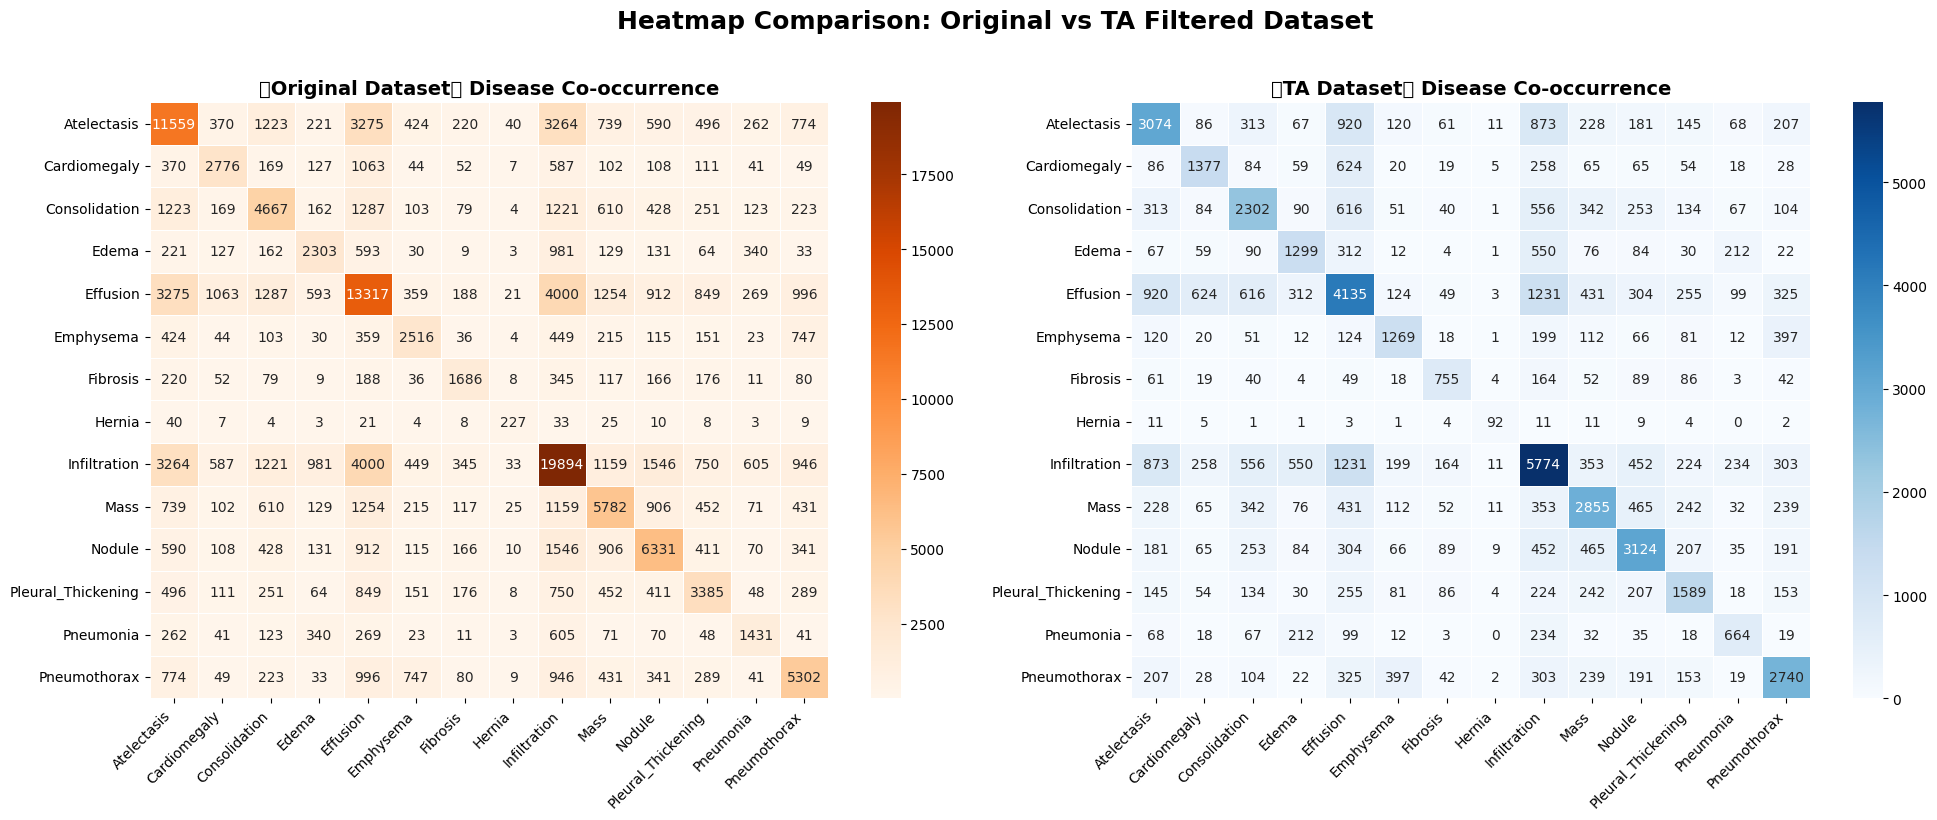

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 讀取兩個 CSV（請替換為你的實際路徑）
df_orig = pd.read_csv('data/original/Data_Entry_2017.csv')
df_ta = pd.read_csv('助教挑選版_train_data.csv')

# 清洗欄位名稱
df_orig.columns = df_orig.columns.str.strip()
df_ta.columns = df_ta.columns.str.strip()

# 2. 定義一個獲取所有疾病標籤（排除 No Finding）的函式
def get_disease_list(df):
    all_labels = set()
    df['Finding Labels'].str.split('|').apply(all_labels.update)
    # 移除 'No Finding'，因為健康的人不會與其他疾病共存
    diseases = [l for l in all_labels if l != 'No Finding' and pd.notna(l)]
    return sorted(diseases)

# 取得兩個資料集聯集的疾病清單，確保兩張圖的 X, Y 軸項目完全一致，方便對照
all_diseases = sorted(list(set(get_disease_list(df_orig) + get_disease_list(df_ta))))

# 3. 定義計算共病矩陣的函式
def calculate_co_matrix(df, disease_list):
    # 建立一個暫時的 One-Hot DataFrame
    temp_df = pd.DataFrame(0, index=df.index, columns=disease_list)
    for label in disease_list:
        temp_df[label] = df['Finding Labels'].apply(lambda x: 1 if pd.notna(x) and label in str(x).split('|') else 0)
    # 計算共病矩陣 (點積)
    co_matrix = temp_df.T.dot(temp_df)
    return co_matrix

# 計算矩陣
matrix_orig = calculate_co_matrix(df_orig, all_diseases)
matrix_ta = calculate_co_matrix(df_ta, all_diseases)

# 4. 開始畫對照圖
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 畫左邊：原始版本
sns.heatmap(matrix_orig, annot=True, cmap="Oranges", fmt="d", linewidths=.5, ax=axes[0])
axes[0].set_title("【Original Dataset】 Disease Co-occurrence", fontsize=14, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

# 畫右邊：助教版本
sns.heatmap(matrix_ta, annot=True, cmap="Blues", fmt="d", linewidths=.5, ax=axes[1])
axes[1].set_title("【TA Dataset】 Disease Co-occurrence", fontsize=14, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.suptitle("Heatmap Comparison: Original vs TA Filtered Dataset", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

/home/sam/Desktop/AI-Final-Project/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 12304 (\N{LEFT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/sam/Desktop/AI-Final-Project/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 12305 (\N{RIGHT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_59629/5337175.py:69: UserWarning: Glyph 12304 (\N{LEFT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59629/5337175.py:69: UserWarning: Glyph 12305 (\N{RIGHT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/sam/Desktop/AI-Final-Project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12304 (\N{LEFT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sam/Desktop/AI-Final-Project/.venv/li

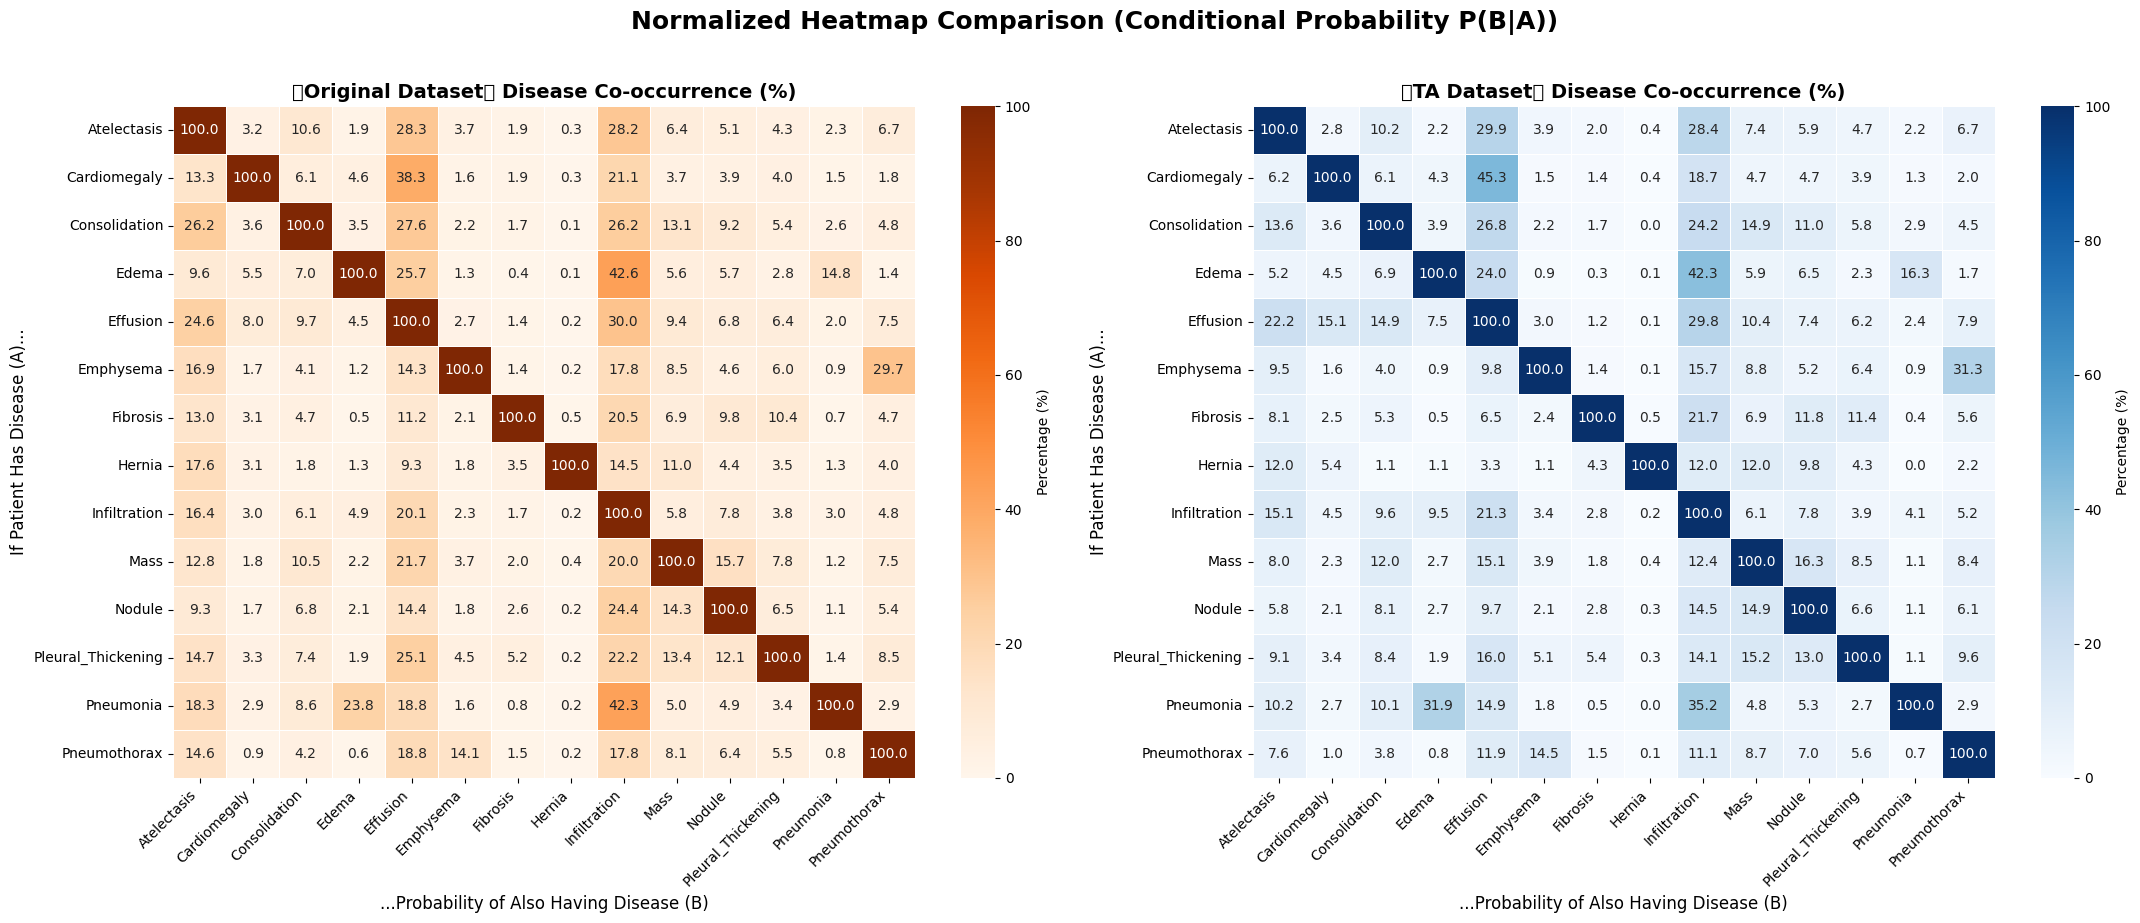

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 讀取兩個 CSV（請替換為你的實際路徑）
df_orig = pd.read_csv('data/original/Data_Entry_2017.csv')
df_ta = pd.read_csv('助教挑選版_train_data.csv')

# 清洗欄位名稱
df_orig.columns = df_orig.columns.str.strip()
df_ta.columns = df_ta.columns.str.strip()

# 2. 定義獲取疾病清單的函式
def get_disease_list(df):
    all_labels = set()
    df['Finding Labels'].str.split('|').apply(all_labels.update)
    diseases = [l for l in all_labels if l != 'No Finding' and pd.notna(l)]
    return sorted(diseases)

all_diseases = sorted(list(set(get_disease_list(df_orig) + get_disease_list(df_ta))))

# 3. 修改後的共病百分比矩陣計算函式
def calculate_co_matrix_percentage(df, disease_list):
    # 建立 One-Hot DataFrame
    temp_df = pd.DataFrame(0, index=df.index, columns=disease_list)
    for label in disease_list:
        temp_df[label] = df['Finding Labels'].apply(lambda x: 1 if pd.notna(x) and label in str(x).split('|') else 0)
    
    # 計算原始共病張數矩陣
    co_matrix = temp_df.T.dot(temp_df)
    
    # 【關鍵修改】轉化為百分比
    # np.diag(co_matrix) 會取出對角線（即各疾病的總張數）
    # 用共病張數除以各疾病總數。為了防止除以 0，使用 np.where 處理
    disease_totals = np.diag(co_matrix)[:, None]  # 轉成行向量以便廣播計算
    
    # 計算百分比矩陣：每一列 (Row) 的數值除以該列的對角線值
    co_matrix_pct = np.where(disease_totals > 0, (co_matrix / disease_totals) * 100, 0)
    
    # 轉回 DataFrame 並保持行列標籤
    return pd.DataFrame(co_matrix_pct, index=disease_list, columns=disease_list)

# 計算百分比矩陣
matrix_orig_pct = calculate_co_matrix_percentage(df_orig, all_diseases)
matrix_ta_pct = calculate_co_matrix_percentage(df_ta, all_diseases)

# 4. 開始畫對照圖
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# 畫左邊：原始版本 (百分比)
# fmt=".1f" 代表顯示小數點後一位，cbar_kws 可以加上 % 符號提示
sns.heatmap(matrix_orig_pct, annot=True, cmap="Oranges", fmt=".1f", linewidths=.5, ax=axes[0], 
            cbar_kws={'label': 'Percentage (%)'}, vmin=0, vmax=100)
axes[0].set_title("【Original Dataset】 Disease Co-occurrence (%)", fontsize=14, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
axes[0].set_ylabel("If Patient Has Disease (A)...", fontsize=12)
axes[0].set_xlabel("...Probability of Also Having Disease (B)", fontsize=12)

# 畫右邊：助教版本 (百分比)
sns.heatmap(matrix_ta_pct, annot=True, cmap="Blues", fmt=".1f", linewidths=.5, ax=axes[1], 
            cbar_kws={'label': 'Percentage (%)'}, vmin=0, vmax=100)
axes[1].set_title("【TA Dataset】 Disease Co-occurrence (%)", fontsize=14, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")
axes[1].set_ylabel("If Patient Has Disease (A)...", fontsize=12)
axes[1].set_xlabel("...Probability of Also Having Disease (B)", fontsize=12)

plt.suptitle("Normalized Heatmap Comparison (Conditional Probability P(B|A))", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()